# Лабораторная работа 5
## Графы
**(13 баллов)**

№ 1

**(2 балла)**

В примере алгоритма поиска в ширину из лекции
(https://cloud.mail.ru/public/9yCy/LitbGAfEg) структура данных граф представлена
словарем. Переделайте этот пример, заменив словарь на реализацию класса Graph из
лекционных материалов.


In [32]:
from collections import deque
import heapq

In [ ]:
def person_is_seller(name):
      return name[0] == 'a'

graph = {}
graph["you"] = ["alice", "bob", "claire"]
graph["bob"] = ["anuj", "peggy"]
graph["alice"] = ["peggy"]
graph["claire"] = ["thom", "jonny"]
graph["anuj"] = []
graph["peggy"] = []
graph["thom"] = []
graph["jonny"] = []

def search(name):
    search_queue = deque()
    search_queue += graph[name]
    searched = set()
    while search_queue:
        person = search_queue.popleft()
        if person not in searched:
            if person_is_seller(person):
                print(person + " is a mango seller!")
                return True
            else:
                search_queue += graph[person]
                searched.add(person)
    return False

search("you")

# пример кода из ссылки, его необходимо изменить

alice is a mango seller!


True

In [ ]:
# ======= КЛАСС ВЕРШИНЫ =======

class Vertex:
    """
    Класс, предоставляющий вершину в графе

    id:                 Уникальный индификатор
    connectedTo:        Словарь смежных вершин и весов ребер
    """

    def __init__(self, key):
        self.id = key
        self.connectedTo = {}

    # Добавляет соседей вершины с указанием весом ребра
    def addNeighbor(self, nbr, weight=0):
        self.connectedTo[nbr] = weight

    def __str__(self):
        return str(self.id) + ' connectedTo: ' + str([x.id for x in self.connectedTo])

    # Получение всех соседних вершин, ключей вершин
    def getConnections(self):
        return self.connectedTo.keys()

    # Полчуение индификатора вершины
    def getId(self):
        return self.id

    # Получение веса ребра до указанного соседа
    def getWeight(self, nbr):
        return self.connectedTo[nbr]

# ======= КЛАСС ГРАФ =======


class Graph:
    """
    Класс, предоставляющий граф

    verList:            Словарь всех вершин графа
    numVertices:        Общее количестов вершин в графе
    """

    def __init__(self):
        self.vertList = {}
        self.numVertices = 0

    # Добавление новой вершины с заданным ключом
    def addVertex(self, key):
        self.numVertices = self.numVertices + 1
        newVertex = Vertex(key)
        self.vertList[key] = newVertex
        return newVertex

    # Получение вершины по ключу
    def getVertex(self, n):
        if n in self.vertList:
            return self.vertList[n]
        else:
            return None

    # Проверка наличия вершины с заданным ключом в графе
    def __contains__(self, n):
        return n in self.vertList
    
    # Позволяет использовать синтаксис g[name] для получения соседей вершины, 
    # возвращает список имен `id` соседних вершин
    def __getitem__(self, key):
        vertex = self.getVertex(key)
        if vertex:
            return [v.getId() for v in vertex.getConnections()]
        else:
            return []

    # Добавлене ребра между вершинами `f` и `t` c указанным весом `count`
    def addEdge(self, f, t, cost=0):
        if f not in self.vertList:
            self.addVertex(f)
        if t not in self.vertList:
            self.addVertex(t)
        self.vertList[f].addNeighbor(self.vertList[t], cost)

    # Получение всех ключей вершин графа
    def getVertices(self):
        return self.vertList.keys()

    # Итератор
    def __iter__(self):
        return iter(self.vertList.values())

In [6]:
# ======= ВСПОМОГАТЕЛЬНЫЕ Ф-ЦИИ =======

# Изменил только ф-цию `person_is_seller`, чтобы наглядно было видно различие
# Ф-ция `search` осталась без изменений

def person_is_seller(name):
    """
    Проверяет, является ли человек продавцом манго

    В данном случае, является ли человек, у которого в конце имени буква 'm'
    """
    return name[-1] == 'm'

def search(name):
    """
    Проверка в ширину

    Алгоритм:
    1. Начинаем с указанной вершины
    2. Проверяем всех друзей первого уровня
    3. Если не нашли продавца, проверяем друзей друзей
    4. Продолжаем, пока не найдем продавца или не проверим всех

    """
    search_queue = deque()
    search_queue += g[name]
    searched = set()

    while search_queue:
        person = search_queue.popleft()

        if person not in searched:
            if person_is_seller(person):
                print(person + " is a mango seller!")
                return True
            else:
                search_queue += g[person]
                searched.add(person)
    return False

# ======= ВЫВОД =======
g = Graph()

# graph["you"] = ["alice", "bob", "claire"]
g.addEdge("you", "alice")
g.addEdge("you", "bob")
g.addEdge("you", "claire")

# graph["bob"] = ["anuj", "peggy"]
g.addEdge("bob", "anuj")
g.addEdge("bob", "peggy")

# graph["alice"] = ["peggy"]
g.addEdge("alice", "peggy")

# graph["claire"] = ["thom", "jonny"]
g.addEdge("claire", "thom")
g.addEdge("claire", "jonny")

# True
search("you")

# Обработчик исклюений не делал, но выведет ошибку
# search("unknown") 

# False - у jonny нет друзей T_T
search("jonny")

thom is a mango seller!


False

№ 2

(2 балла)

Реализуйте программу, которая по заданному в виде списка смежности графу строит
обращённый граф (тоже в виде списка смежности). Обращённый граф получается
изменением направления всех рёбер исходного графа. Используйте класс Graph из
лекционных материалов.

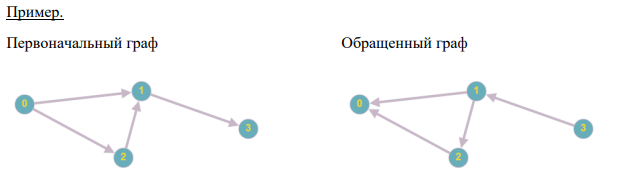

In [25]:
# ======= ВСПОМОГАТЕЛЬНЫЕ Ф-ЦИИ =======

# Общая ф-ция реверса графа
def reverseGraph(graph):
    reversed_graph = Graph()
    # Создание вершин
    for vertex_key in graph.getVertices():
        reversed_graph.addVertex(vertex_key)

    # Перебор всех ребер
    for vertex in graph:
        from_vert = vertex.getId()
        
        # Перебор всех соседей в текущей вершине
        for neighbor in vertex.getConnections():
            to_vert = neighbor.getId()
            
            #Если понадобится, то можно прикрутить вес ребра
            # weight = vertex.getWeight(neighbor)
            
            # Меняем направление ребра
            reversed_graph.addEdge(to_vert, from_vert)
    return reversed_graph

# ======= ВЫВОД =======

g = Graph()
g.addEdge(0, 1)
g.addEdge(0, 2)
g.addEdge(1, 3)
g.addEdge(2, 1)

print("Original graph edges:")
for vert in g:
    for neighbor in vert.getConnections():
        print("( %s, %s )" % (vert.getId(), neighbor.getId()))

print("\nReversed graph edges:")
reversed_g = reverseGraph(g)
for vert in reversed_g:
    for neighbor in vert.getConnections():
        print("( %s, %s )" % (vert.getId(), neighbor.getId()))


Original graph edges:
( 0, 1 )
( 0, 2 )
( 1, 3 )
( 2, 1 )

Reversed graph edges:
( 1, 0 )
( 1, 2 )
( 2, 0 )
( 3, 1 )


№ 3

(4 балла)

Пусть у вас имеется следующий рецепт блинов: одно яйцо, одна чашка блинной смеси, одна
столовая ложка растительного масла и 3/4 чашки молока. Чтобы нажарить блинов, вам
нужно разогреть сковородку, смешать вместе все ингредиенты и выливать смесь по ложке
на горячую сковороду. Когда блин начинает пузыриться, переверните его и дождитесь, пока
нижняя сторона не станет золотистой. Перед тем, как приступить к поеданию блинов,
полейте их сиропом. Весь процесс показан в виде графа

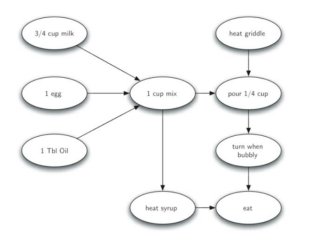

Напишите программу, которая при помощи поиска в глубину (Depth-first search, DFS)
проведет топологическую сортировку представленного графа и выдаст вариант корректной
последовательности шагов. Например:

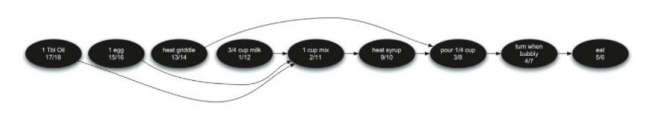

Используйте класс Graph из лекционных материалов.

# От себя

Видео материалл для анализа DFS и топологической сортировки:<br/>
https://youtu.be/3-XLRh2M5YI?si=7wN8LfsofyyDEixh - DFS<br/>
https://youtu.be/o0P8oNXoA_w?si=Rc03-g3zLyklsnQQ - ТПС

In [30]:
# ======= ВСПОМОГАТЕЛЬНЫЕ Ф-ЦИИ =======

def find_sources(graph):
    """
    Поиск вершин без входящих ребер (истоки)
    
    Истоки - это вершины, которые никто не требует для своего выполнения,
    их можно выполнить первыми
    """
    # Словарь для подсчета входящих ребер
    in_degree = {vertex_id: 0 for vertex_id in graph.getVertices()}
    
    # Подсчет входящих ребер для каждой вершины
    for vertex_id in graph.getVertices():
        for neighbor_id in graph[vertex_id]:
            in_degree[neighbor_id] += 1
    
    # Возвращаем вершины с нулевым количеством входящих ребер
    return [vertex_id for vertex_id, degree in in_degree.items() if degree == 0]


def dfs_topological_sort(graph):
    """
    Топологическая сортировка графа с использованием DFS (поиска в глубину)
    
    Алгоритм:
    1. Выбираем вершину без входящих ребер (исток)
    2. Рекурсивно обходим все ее соседей
    3. Добавляем вершину в результат после обработки всех ее соседей
    4. Результат нужно развернуть, так как вершины добавляются в обратном порядке
    
    Возвращает:
    Список вершин в топологическом порядке или пустой список при наличии циклов
    """
    
    # Множество для отслеживания посещенных вершин / вершин в текущем пути
    visited = set()
    on_stack = set()

    result = []
    
    def dfs(vertex_id):
        """Рекурсивная функция DFS для обхода графа"""
        # Если вершина уже в текущем пути - обнаружен цикл
        if vertex_id in on_stack:
            return False
        
        # Если вершина уже посещена - пропускаем
        if vertex_id in visited:
            return True
        
        # Помечаем вершину как посещенную и добавляем в текущий путь
        visited.add(vertex_id)
        on_stack.add(vertex_id)
        
        # Рекурсивно обходим всех соседей
        for neighbor_id in graph[vertex_id]:
            if not dfs(neighbor_id):
                return False
        
        # Убираем вершину из текущего пути
        on_stack.remove(vertex_id)

        result.append(vertex_id)
        return True
    
    # Список истоков
    sources = find_sources(graph)

    # Запускаем DFS от каждого истока
    for source in sources:
        if not dfs(source):
            print("A cycle in a graph")
            return []
        
    # Проверка, если мы прошли не все вершины
    #  
    all_vertices = set(graph.getVertices())
    if visited != all_vertices:
        print("Not all the peaks have been passed")
        
        # Пытаемся обработать оставшиеся вершины
        for vertex_id in graph.getVertices():
            if vertex_id not in visited:
                if not dfs(vertex_id):
                    print("A cycle in a graph")
                    return []
    
    # Разворачиваем результат, так как вершины добавлялись в обратном порядке
    return result[::-1]

# ======= ВЫВОД =======

g = Graph()
g.addEdge('3/4 cup milk', '1 cup mix')
g.addEdge('1 egg', '1 cup mix')
g.addEdge('1 Tbl Oil', '1 cup mix')

g.addEdge('1 cup mix', 'pour 1/4 cup')
g.addEdge('1 cup mix', 'heat syrup')

g.addEdge('heat griddle', 'pour 1/4 cup')

g.addEdge('pour 1/4 cup', 'turn when bubbly')

g.addEdge('turn when bubbly', 'eat')
g.addEdge('heat syrup', 'eat')

# Тестовый вариант, где есть цикл и не все пройденные вершины 
# g = Graph()
# g.addEdge('heat griddle', 'pour 1/4 cup')
# g.addEdge('pour 1/4 cup', 'turn when bubbly')
# g.addEdge('turn when bubbly', 'heat griddle') #
# g.addEdge('turn when bubbly', 'eat')


sorted_steps = dfs_topological_sort(g)

if sorted_steps:
    print(" -> ".join(sorted_steps))
else:
    print("It is not possible to perform topological sorting")


heat griddle -> 1 Tbl Oil -> 1 egg -> 3/4 cup milk -> 1 cup mix -> heat syrup -> pour 1/4 cup -> turn when bubbly -> eat


№ 4

(5 баллов)

У вас имеется список городов и набор автобусных маршрутов между ними. Маршруты
однонаправленные, т.е. маршрут вида «город А – город Б» означает, что можно поехать из
города А в город Б, а обратного проезда нет.

Пользователь вводит два города. Ваша программа должна определить минимальный по
количеству километров возможный путь от первого до второго города, или сообщение, что
пути между городами нет. Нужно вывести как количество километров, так и получившейся
путь.

Для решения задачи используйте алгоритм Дейкстры и класс Graph из лекционных
материалов. Список городов и маршрутов возьмите согласно вашему варианту. Расстояние
между городами найдите в интернете самостоятельно.

Также необходимо нарисовать граф вашего варианта (например, здесь
https://graphonline.ru/) и приложить его в ваш отчет.

Вариант 4.<br/>
Города:<br/>
Мариинск, Яя, Яшкино, Юрга, Анжеро-Судженск, Кемерово, Томск.<br/>
Маршруты:<br/>
Мариинск – Яя<br/>
Мариинск – Яшкино<br/>
Мариинск – Юрга<br/>
Мариинск – Анжеро-Судженск<br/>
Яя – Кемерово<br/>
Яшкино – Яя<br/>
Яшкино – Томск<br/>
Юрга – Яшкино<br/>
Юрга – Томск<br/>
Юрга – Анжеро-Судженск<br/>
Томск – Кемерово<br/>

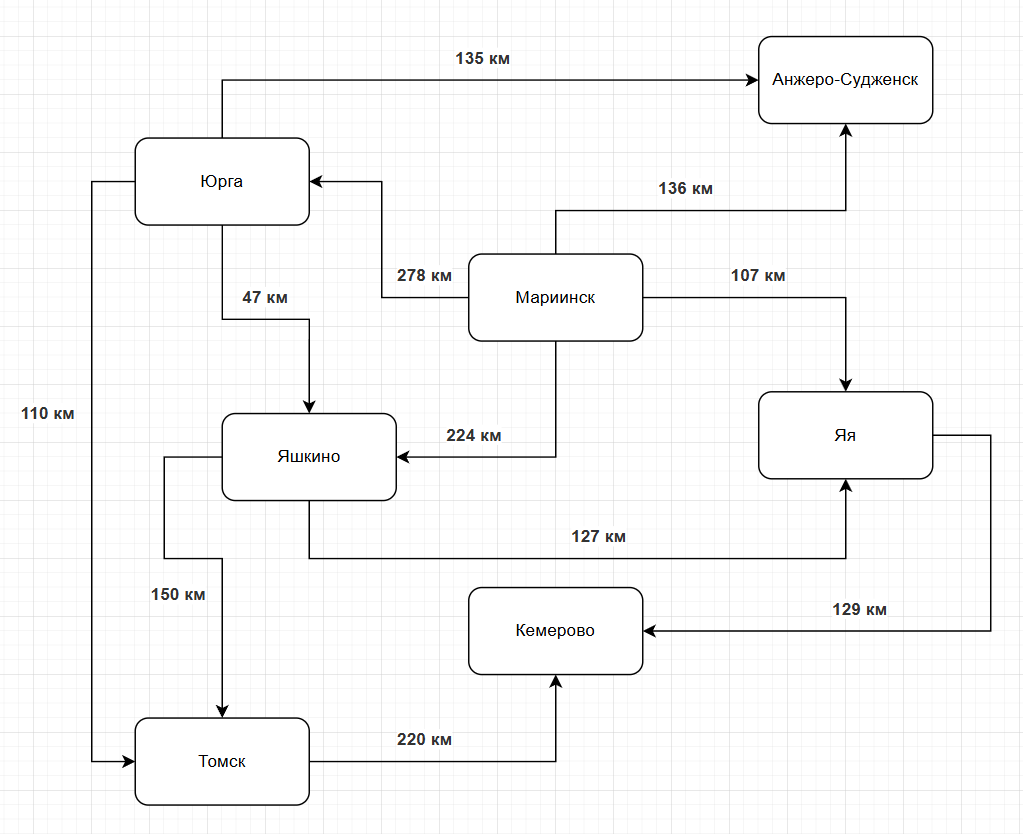

# Алгорит Дейкстра

https://youtu.be/fA_xvuqzuGs?si=-txwCqewyTuaQDG4 - Идея<br/>
https://youtu.be/J-7MzbEtTR0?si=6KUEAS1ZfWuwj3UO - Алгоритм

In [ ]:
# ======= АЛГОРИТМ ДЕЙКСТРЫ =======

def dijkstra(graph, start_key):
    # Инициализация. Бесконечность для всех, кроме старта
    distances = {v: float('inf') for v in graph.getVertices()}
    distances[start_key] = 0
    
    # Очередь с приоритетом хранит кортежи: (расстояние, ключ_вершины)
    pq = [(0, start_key)]
    
    # Словарь для восстановления пути: key -> parent_key
    previous = {v: None for v in graph.getVertices()}

    while pq:
        # Берем вершину с минимальным расстоянием
        current_dist, current_vert_key = heapq.heappop(pq)
        
        # Если извлеченное расстояние больше уже известного кратчайшего, пропускаем
        # Это может случиться, если одна и та же вершина была добавлена в очередь несколько раз
        if current_dist > distances[current_vert_key]:
            continue
            
        # Возвращает объект Vertex
        current_vert_obj = graph.getVertex(current_vert_key)

        # Проходим по соседям `current_vert_obj`
        for neighbor_obj in current_vert_obj.getConnections():
            neighbor_key = neighbor_obj.getId()
            weight = current_vert_obj.getWeight(neighbor_obj)
            
            new_distance = current_dist + weight

            # Если нашли путь короче, обновляем дистанцию и предшественника
            # Добавляем также в очередь
            if new_distance < distances[neighbor_key]:
                distances[neighbor_key] = new_distance
                previous[neighbor_key] = current_vert_key
                heapq.heappush(pq, (new_distance, neighbor_key))
                
    return distances, previous

In [41]:
# ======= ВСПОМОГАТЕЛЬНЫЕ Ф-ЦИИ =======

def print_result(distances, previous, start, end):
    # Если расстояние осталось бесконечным, пути нет
    if distances[end] == float('inf'):
        print(f"\nRoutes between cities {start} and {end} no.")
        return

    # Восстановление пути с конца по словарю
    # Пока не дойдет до источника со значением None
    path = []
    current = end
    while current is not None:
        path.append(current)
        current = previous[current]
    
    # Разворачиваем список, чтобы получить путь от начала к концу
    path = path[::-1]
    
    print(f"\nMinimum number of kilometers: {distances[end]} км")
    print(f"The resulting path: {' -> '.join(path)}")

# ======= ВЫВОД =======

g = Graph()

g.addEdge("Мариинск", "Яя", 107)
g.addEdge("Мариинск", "Яшкино", 224)
g.addEdge("Мариинск", "Юрга", 278)
g.addEdge("Мариинск", "Анжеро-Судженск", 136)
g.addEdge("Яя", "Кемерово", 129)
g.addEdge("Яшкино", "Яя", 127)
g.addEdge("Яшкино", "Томск", 150)
g.addEdge("Юрга", "Яшкино", 47)
g.addEdge("Юрга", "Томск", 110)
g.addEdge("Юрга", "Анжеро-Судженск", 135)
g.addEdge("Томск", "Кемерово", 220)


print("List of cities:", ", ".join(g.getVertices()))

start_city = input("\nEnter the first city (from where): ").strip()
end_city = input("Enter the second city (where to): ").strip()

# Проверка валидности ввода
if start_city not in g or end_city not in g:
    print("\nError")
# Расчет и вывод
else:
    dists, prevs = dijkstra(g, start_city)
    print_result(dists, prevs, start_city, end_city)

List of cities: Мариинск, Яя, Яшкино, Юрга, Анжеро-Судженск, Кемерово, Томск

Minimum number of kilometers: 303 км
The resulting path: Юрга -> Яшкино -> Яя -> Кемерово
